# Mineração de Regras de Associação
### Teoria, Implementação e Benchmark: Apriori vs FP-Growth

---

Este notebook cobre de forma completa o processo de extração de regras de associação a partir de dados transacionais. A ordem de apresentação é:

1. **Regras de Associação e Métricas** — o que estamos buscando e como avaliamos
2. **Algoritmo Apriori** — a abordagem clássica e seus gargalos
3. **Algoritmo FP-Growth** — a evolução eficiente
4. **Benchmark Configurável** — comparativo prático com dados sintéticos

---
## 0. Imports e Setup

In [1]:
%pip install mlxtend pandas numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

# Estilo dos gráficos
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.size': 11,
})

print('✅ Imports OK')

✅ Imports OK


---
# Parte 1 — Regras de Associação e Métricas

## O que é uma Regra de Associação?

Dado um conjunto de transações, queremos extrair regras da forma $X \Rightarrow Y$, onde $X$ e $Y$ são **itemsets disjuntos** ($X \cap Y = \emptyset$). Essa regra expressa um indício aprendido com os dados: se $X$ ocorre em uma transação, então $Y$ também tende a ocorrer.

**Exemplo clássico:** `{Fraldas} ⟹ {Cerveja}` — descoberta em análises de supermercado indicando que quem compra fraldas tende a comprar cerveja.

O processo completo tem **duas etapas**:

| Etapa | Objetivo | Algoritmo |
|-------|----------|-----------|
| 1. Itemsets Frequentes | Encontrar conjuntos de itens que aparecem com frequência mínima | **Apriori / FP-Growth** |
| 2. Geração de Regras | Calcular métricas (confiança, lift) e filtrar | `mlxtend.association_rules` |

## Métricas de Avaliação

### 1. Suporte (Support)
Indica a **frequência relativa** com que a combinação $X \cup Y$ aparece no total de transações:

$$\text{Support}(X \Rightarrow Y) = \frac{\text{frequência}(X \cup Y)}{N}$$

> 📌 Suporte baixo → o par $(X, Y)$ é raro → provavelmente irrelevante.

---

### 2. Confiança (Confidence)
Mede a proporção de transações com $X$ que **também contêm** $Y$. É literalmente $P(Y \mid X)$:

$$\text{Confidence}(X \Rightarrow Y) = \frac{\text{Support}(X \Rightarrow Y)}{\text{Support}(X)}$$

> ⚠️ **Armadilha:** Se um item aparece em 90% das transações (ex: `{Sal}`), qualquer regra com ele como consequente terá confiança artificialmente alta. Não indica causalidade real.

---

### 3. Lift (Levantamento ? de que ?)
Mede o **quanto $X$ influencia $Y$** além do que ocorreria ao acaso. É a métrica mais robusta:

$$\text{Lift}(X \Rightarrow Y) = \frac{\text{Confidence}(X \Rightarrow Y)}{\text{Support}(Y)} = \frac{P(Y \mid X)}{P(Y)}$$

| Valor do Lift | Interpretação |
|---------------|---------------|
| **Lift > 1** | $X$ e $Y$ são **positivamente correlacionados** — ocorrem juntos mais que o esperado |
| **Lift = 1** | $X$ e $Y$ são **independentes** — conhecer $X$ não muda a chance de $Y$ |
| **Lift < 1** | $X$ e $Y$ são **substitutos** — quem compra $X$ tem *menos* chance de comprar $Y$ |

## Calculando as Métricas na Mão

Vamos ilustrar com um dataset mínimo antes de usar a biblioteca.

In [3]:
# Dataset de exemplo
transacoes = [
    ['Pão', 'Leite', 'Manteiga'],
    ['Pão', 'Leite'],
    ['Manteiga'],
    ['Leite', 'Manteiga'],
    ['Pão', 'Leite', 'Manteiga'],
    ['Pão', 'Leite'],
    ['Manteiga'],
    ['Pão', 'Manteiga', 'Leite'],
    ['Pão', 'Leite', 'Manteiga'],
    ['Pão', 'Leite'],
    ['Pão']
]

N = len(transacoes)
print(f"Total de transações (N): {N}")

# Contagens
freq = lambda items: sum(1 for t in transacoes if all(i in t for i in items))

sup_pao       = freq(['Pão']) / N
sup_leite     = freq(['Leite']) / N
sup_pao_leite = freq(['Pão', 'Leite']) / N

confidence    = sup_pao_leite / sup_pao
lift          = confidence / sup_leite

print(f"\n--- Regra: Pão ⟹ Leite ---")
print(f"  Support(Pão)         = {sup_pao:.2f}  ({freq(['Pão'])}/{N} transações)")
print(f"  Support(Leite)       = {sup_leite:.2f}  ({freq(['Leite'])}/{N} transações)")
print(f"  Support(Pão ∪ Leite) = {sup_pao_leite:.2f}  ({freq(['Pão','Leite'])}/{N} transações)")
print(f"  Confidence           = {confidence:.2f}  → em {confidence*100:.0f}% das vezes que Pão aparece, Leite também está")
print(f"  Lift                 = {lift:.2f}  → Pão torna Leite {lift:.1f}x mais provável que ao acaso")

Total de transações (N): 11

--- Regra: Pão ⟹ Leite ---
  Support(Pão)         = 0.73  (8/11 transações)
  Support(Leite)       = 0.73  (8/11 transações)
  Support(Pão ∪ Leite) = 0.64  (7/11 transações)
  Confidence           = 0.88  → em 88% das vezes que Pão aparece, Leite também está
  Lift                 = 1.20  → Pão torna Leite 1.2x mais provável que ao acaso


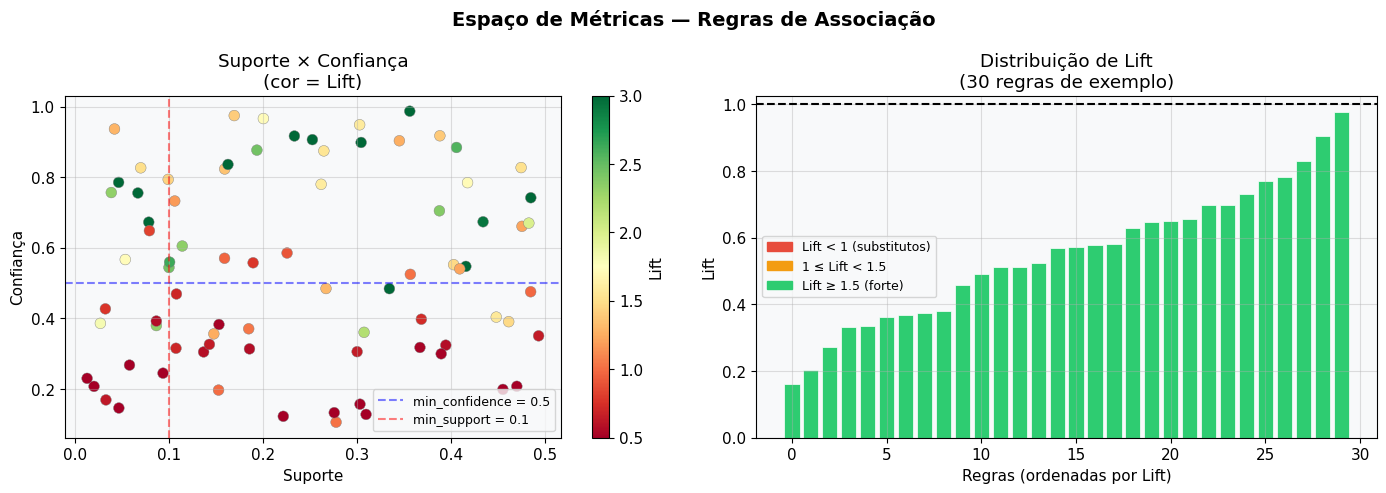

In [4]:
# Visualizando o espaço Suporte x Confiança x Lift
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Espaço de Métricas — Regras de Associação', fontsize=14, fontweight='bold')

# Simulando algumas regras hipotéticas
np.random.seed(42)
n_regras = 80
suporte    = np.random.uniform(0.01, 0.5, n_regras)
confianca  = np.random.uniform(0.1, 1.0, n_regras)
lift_vals  = confianca / np.random.uniform(0.1, 0.8, n_regras)

# Plot 1: Support vs Confidence
sc1 = axes[0].scatter(suporte, confianca, c=lift_vals, cmap='RdYlGn', s=60, edgecolors='gray', linewidth=0.3, vmin=0.5, vmax=3)
axes[0].axhline(0.5, color='blue', linestyle='--', alpha=0.5, label='min_confidence = 0.5')
axes[0].axvline(0.1, color='red',  linestyle='--', alpha=0.5, label='min_support = 0.1')
axes[0].set_xlabel('Suporte')
axes[0].set_ylabel('Confiança')
axes[0].set_title('Suporte × Confiança\n(cor = Lift)')
axes[0].legend(fontsize=9)
plt.colorbar(sc1, ax=axes[0], label='Lift')

# Plot 2: Lift distribution
cores = ['#e74c3c' if l < 1 else '#2ecc71' if l > 1.5 else '#f39c12' for l in lift_vals]
axes[1].bar(range(len(lift_vals[:30])), sorted(lift_vals)[:30], color=sorted(cores)[:30], edgecolor='white', linewidth=0.5)
axes[1].axhline(1.0, color='black', linestyle='--', linewidth=1.5, label='Lift = 1 (independência)')
axes[1].set_xlabel('Regras (ordenadas por Lift)')
axes[1].set_ylabel('Lift')
axes[1].set_title('Distribuição de Lift\n(30 regras de exemplo)')
red_p   = mpatches.Patch(color='#e74c3c', label='Lift < 1 (substitutos)')
yel_p   = mpatches.Patch(color='#f39c12', label='1 ≤ Lift < 1.5')
grn_p   = mpatches.Patch(color='#2ecc71', label='Lift ≥ 1.5 (forte)')
axes[1].legend(handles=[red_p, yel_p, grn_p], fontsize=9)

plt.tight_layout()
plt.show()

## Por que precisamos de algoritmos?

Sem algoritmos inteligentes, teríamos que testar **todas as combinações possíveis** de itens:

$$O(N \cdot 2^d)$$

Onde $N$ é o número de transações e $d$ o número de itens únicos ($2^d$ é o **Power Set**).

 Itens únicos (d)                         Combinações (2^d) Operações (N=1M × 2^d)                             Status
               10                                     1,024               1.02e+09                ✅ Viável (segundos)
               20                                 1,048,576               1.05e+12                 ✅ Viável (minutos)
               30                             1,073,741,824               1.07e+15                       ⚠️ No limite
               50                     1,125,899,906,842,624               1.13e+21                  ❌ Inviável (anos)
              100 1,267,650,600,228,229,401,496,703,205,376               1.27e+36 ❌ Impossível (> idade do universo)


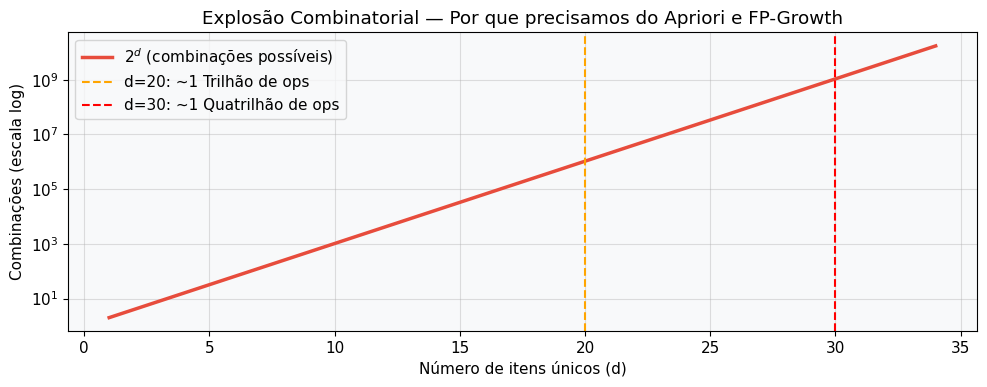

In [5]:
# Tabela de complexidade
dados = {
    'Itens únicos (d)':    [10, 20, 30, 50, 100],
    'Combinações (2^d)':   [2**10, 2**20, 2**30, 2**50, 2**100],
    'Operações (N=1M × 2^d)': [int(1e6 * 2**d) for d in [10, 20, 30, 50, 100]],
    'Status': ['✅ Viável (segundos)', '✅ Viável (minutos)', '⚠️ No limite', '❌ Inviável (anos)', '❌ Impossível (> idade do universo)']
}
df_complexidade = pd.DataFrame(dados)
df_complexidade['Combinações (2^d)'] = df_complexidade['Combinações (2^d)'].apply(lambda x: f'{x:,.0f}')
df_complexidade['Operações (N=1M × 2^d)'] = df_complexidade['Operações (N=1M × 2^d)'].apply(lambda x: f'{x:.2e}')
print(df_complexidade.to_string(index=False))

# Gráfico
d_vals = np.arange(1, 35)
fig, ax = plt.subplots(figsize=(10, 4))
ax.semilogy(d_vals, 2**d_vals, color='#e74c3c', linewidth=2.5, label='$2^d$ (combinações possíveis)')
ax.axvline(20, color='orange', linestyle='--', label='d=20: ~1 Trilhão de ops')
ax.axvline(30, color='red',    linestyle='--', label='d=30: ~1 Quatrilhão de ops')
ax.set_xlabel('Número de itens únicos (d)')
ax.set_ylabel('Combinações (escala log)')
ax.set_title('Explosão Combinatorial — Por que precisamos do Apriori e FP-Growth')
ax.legend()
plt.tight_layout()
plt.show()

---
# Parte 2 — O Algoritmo Apriori

## Ideia Central: a Propriedade Antimonotônica

> **"Se um itemset é infrequente, todos os seus superconjuntos também serão obrigatoriamente infrequentes."**

Isso significa: se o suporte de `{A}` é baixo, é matematicamente impossível que `{A, B}`, `{A, C}` ou `{A, B, C}` sejam frequentes — pois qualquer conjunto que contém `{A}` só pode aparecer em transações onde `{A}` já aparece.

## Poda (Pruning)
Ao descobrir que `{A}` não atinge o suporte mínimo, o algoritmo **elimina** imediatamente qualquer candidato futuro que contenha `{A}`. Ele nem volta ao banco de dados para contar esses conjuntos maiores.

## Passo a Passo

O algoritmo funciona construindo conjuntos de tamanho $k$, começando do $k=1$ até não encontrar mais nada.

1. **O Filtro Inicial ($k=1$):** O algoritmo começa analisando os itens individualmente. Ele faz uma varredura completa nas transações e descarta tudo o que for raro (abaixo do `min_support`). O resultado é uma lista de itens "sobreviventes" que aparecem com a frequência mínima exigida.

2. **A Tentativa de achar itemsets maiores:** Com base nos itens que sobreviveram à etapa anterior, o algoritmo tenta formar grupos um pouco maiores (tamanho $k+1$). Exemplo: Se `{Pão}` e `{Leite}` são frequentes isoladamente, ele cria o candidato `{Pão, Leite}` para o próximo nível.

3. **A Poda / Pruning:** Antes de gastar tempo lendo o banco de dados novamente, o algoritmo aplica o **pruning** da seguinte forma: ele verifica se todos os "pedaços" (subconjuntos) desse novo grupo eram frequentes na etapa anterior. Se você está testando o grupo `{Pão, Leite, Café}`, mas já sabe que `{Pão, Café}` foi descartado por ser raro no nível anterior, você **elimina** o grupo inteiro agora mesmo. Não se gasta processamento contando algo que, matematicamente, não tem chance de ser frequente.

4. **Scan:** O algoritmo volta ao banco de dados, mas **apenas** para contar a frequência dos candidatos que sobreviveram a Poda. O resultado sao conjuntos que possuem suporte suficiente nas transações.

5. **Ciclo:** O processo se repete aumentando o tamanho dos grupos ($k=2 \rightarrow 3 \rightarrow 4...$) usando os sobreviventes do nível anterior como base. O ciclo encerra quando:

    - Não for mais possível formar novos candidatos a partir dos itens frequentes atuais.
    - Nenhum candidato novo conseguir atingir o suporte mínimo no scan.


A Poda (Passo 3) evita que o computador tente contar bilhões de combinações inúteis, agindo como um filtro que barra candidatos ruins antes mesmo de eles chegarem à fase cara de leitura do banco de dados.


## Gargalos do Apriori

| Problema | Detalhes |
|----------|----------|
| **Múltiplos Scans** | Para um padrão de tamanho $k$, lê o banco de dados $k$ vezes |
| **Explosão de Candidatos** | Com 10.000 itens frequentes, gera ~50 milhões de candidatos de tamanho 2 para testar |

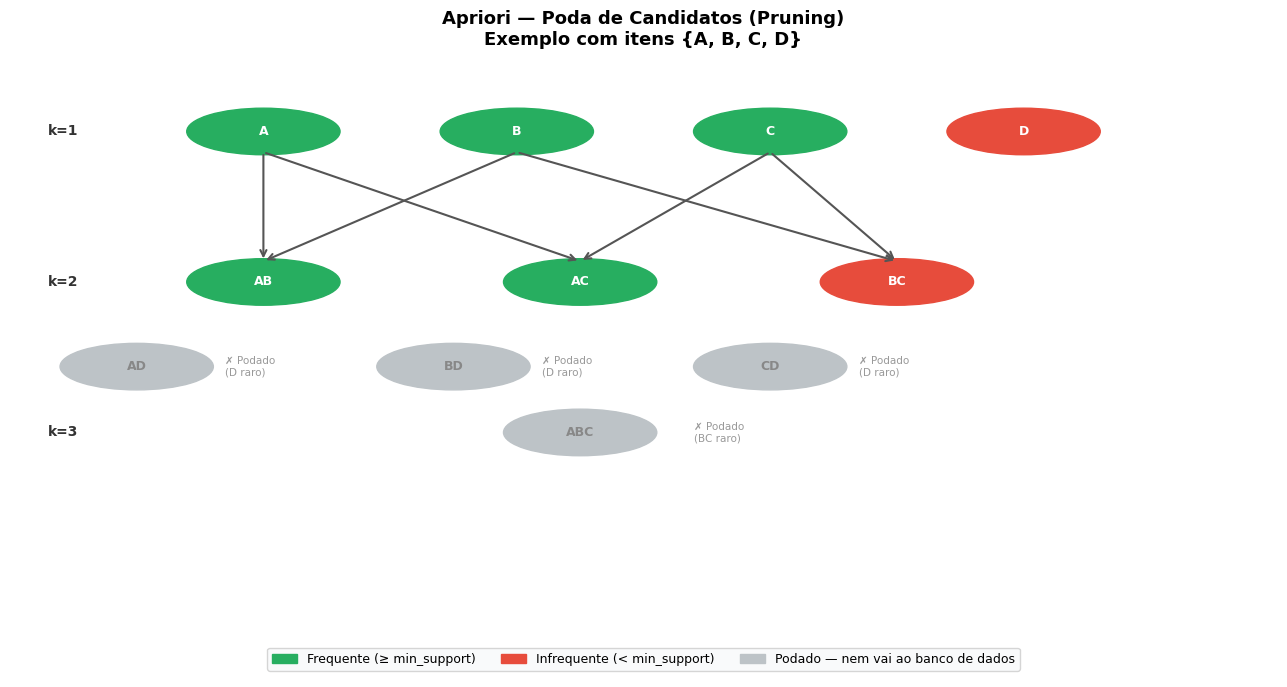

In [6]:
# Visualizando a poda do Apriori com árvore de candidatos
fig, ax = plt.subplots(figsize=(13, 7))
ax.set_xlim(0, 10)
ax.set_ylim(0, 6.5)
ax.axis('off')
ax.set_facecolor('white')
fig.patch.set_facecolor('white')
ax.set_title('Apriori — Poda de Candidatos (Pruning)\nExemplo com itens {A, B, C, D}', fontsize=13, fontweight='bold', pad=15)

def draw_node(ax, x, y, label, color, fontcolor='white', size=0.55, fs=9):
    ellipse = mpatches.Ellipse((x, y), size * 2.2, size * 0.9, color=color, zorder=3)
    ax.add_patch(ellipse)
    ax.text(x, y, label, ha='center', va='center', fontsize=fs, color=fontcolor, fontweight='bold', zorder=4)

def draw_edge(ax, x1, y1, x2, y2, color='#555', style='-'):
    ax.annotate('', xy=(x2, y2 + 0.22), xytext=(x1, y1 - 0.22),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.5, linestyle=style))

# K=1
k1 = [('A', 2.0, 5.8, '#27ae60'), ('B', 4.0, 5.8, '#27ae60'),
      ('C', 6.0, 5.8, '#27ae60'), ('D', 8.0, 5.8, '#e74c3c')]
for label, x, y, c in k1:
    draw_node(ax, x, y, label, c)
ax.text(0.3, 5.8, 'k=1', fontsize=10, va='center', color='#333', fontweight='bold')

# K=2 (D podado → AB, AC, BC gerados; AD, BD, CD eliminados)
k2_ok  = [('AB', 2.0, 4.2, '#27ae60'), ('AC', 4.5, 4.2, '#27ae60'), ('BC', 7.0, 4.2, '#e74c3c')]
k2_pod = [('AD', 1.0, 3.3, '#bdc3c7'), ('BD', 3.5, 3.3, '#bdc3c7'), ('CD', 6.0, 3.3, '#bdc3c7')]
for label, x, y, c in k2_ok:
    draw_node(ax, x, y, label, c)
for label, x, y, c in k2_pod:
    draw_node(ax, x, y, label, c, fontcolor='#888')
    ax.text(x + 0.7, y, '✗ Podado\n(D raro)', fontsize=7.5, va='center', color='#999')
ax.text(0.3, 4.2, 'k=2', fontsize=10, va='center', color='#333', fontweight='bold')

# Arestas k1→k2
for label, x2, y2, _ in k2_ok:
    for l1, x1, y1, _ in k1:
        if l1 in label and _ != '#bdc3c7':
            draw_edge(ax, x1, y1, x2, y2)

# K=3 (só ABC possível, mas BC era infrequente → ABC podado)
draw_node(ax, 4.5, 2.6, 'ABC', '#bdc3c7', fontcolor='#888')
ax.text(5.4, 2.6, '✗ Podado\n(BC raro)', fontsize=7.5, va='center', color='#999')
ax.text(0.3, 2.6, 'k=3', fontsize=10, va='center', color='#333', fontweight='bold')

# Legendas
verde  = mpatches.Patch(color='#27ae60', label='Frequente (≥ min_support)')
verm   = mpatches.Patch(color='#e74c3c', label='Infrequente (< min_support)')
cinza  = mpatches.Patch(color='#bdc3c7', label='Podado — nem vai ao banco de dados')
ax.legend(handles=[verde, verm, cinza], loc='lower center', fontsize=9, ncol=3)

plt.tight_layout()
plt.show()

## Apriori com mlxtend 

In [7]:
# Dataset de mercearia
dataset_mercearia = [
    ['Pão', 'Leite', 'Manteiga', 'Ovos'],
    ['Pão', 'Leite', 'Queijo'],
    ['Pão', 'Manteiga'],
    ['Leite', 'Manteiga', 'Queijo', 'Ovos'],
    ['Pão', 'Leite', 'Manteiga'],
    ['Pão', 'Ovos'],
    ['Leite', 'Queijo'],
    ['Pão', 'Leite', 'Ovos', 'Queijo'],
    ['Manteiga', 'Queijo'],
    ['Pão', 'Leite', 'Manteiga', 'Queijo', 'Ovos'],
]

# Codificação One-Hot
te = TransactionEncoder()
df_ohe = pd.DataFrame(te.fit(dataset_mercearia).transform(dataset_mercearia), columns=te.columns_)

print("Matriz One-Hot (cada linha = transação, cada coluna = item):")
print(df_ohe.astype(int).to_string())

Matriz One-Hot (cada linha = transação, cada coluna = item):
   Leite  Manteiga  Ovos  Pão  Queijo
0      1         1     1    1       0
1      1         0     0    1       1
2      0         1     0    1       0
3      1         1     1    0       1
4      1         1     0    1       0
5      0         0     1    1       0
6      1         0     0    0       1
7      1         0     1    1       1
8      0         1     0    0       1
9      1         1     1    1       1


In [8]:
# Rodando o Apriori
MIN_SUPPORT = 0.3

frequent_itemsets_apriori = apriori(df_ohe, min_support=MIN_SUPPORT, use_colnames=True)
frequent_itemsets_apriori['tamanho'] = frequent_itemsets_apriori['itemsets'].apply(len)
frequent_itemsets_apriori = frequent_itemsets_apriori.sort_values('support', ascending=False)

print(f"Itemsets frequentes encontrados pelo Apriori (min_support={MIN_SUPPORT}):")
print(frequent_itemsets_apriori.to_string(index=False))

Itemsets frequentes encontrados pelo Apriori (min_support=0.3):
 support                           itemsets  tamanho
     0.7                 frozenset({Leite})        1
     0.7                   frozenset({Pão})        1
     0.6              frozenset({Manteiga})        1
     0.6                frozenset({Queijo})        1
     0.5                  frozenset({Ovos})        1
     0.5            frozenset({Pão, Leite})        2
     0.5         frozenset({Queijo, Leite})        2
     0.4       frozenset({Leite, Manteiga})        2
     0.4           frozenset({Ovos, Leite})        2
     0.4         frozenset({Pão, Manteiga})        2
     0.4             frozenset({Ovos, Pão})        2
     0.3        frozenset({Ovos, Manteiga})        2
     0.3      frozenset({Queijo, Manteiga})        2
     0.3          frozenset({Ovos, Queijo})        2
     0.3           frozenset({Pão, Queijo})        2
     0.3 frozenset({Ovos, Leite, Manteiga})        3
     0.3  frozenset({Pão, Leite, Ma

In [9]:
# Gerando regras de associação a partir dos itemsets frequentes
regras = association_rules(frequent_itemsets_apriori, metric='lift', min_threshold=1.0, num_itemsets=len(frequent_itemsets_apriori))
regras = regras[['antecedents', 'consequents', 'support', 'confidence', 'lift']]
regras = regras.sort_values('lift', ascending=False)

print("Regras de Associação geradas (filtro: lift ≥ 1.0):")
print(regras.to_string(index=False))

Regras de Associação geradas (filtro: lift ≥ 1.0):
                 antecedents                  consequents  support  confidence     lift
frozenset({Leite, Manteiga})            frozenset({Ovos})      0.3    0.750000 1.500000
           frozenset({Ovos}) frozenset({Leite, Manteiga})      0.3    0.600000 1.500000
   frozenset({Ovos, Queijo})           frozenset({Leite})      0.3    1.000000 1.428571
          frozenset({Leite})     frozenset({Pão, Queijo})      0.3    0.428571 1.428571
          frozenset({Leite})  frozenset({Ovos, Manteiga})      0.3    0.428571 1.428571
 frozenset({Ovos, Manteiga})           frozenset({Leite})      0.3    1.000000 1.428571
    frozenset({Pão, Queijo})           frozenset({Leite})      0.3    1.000000 1.428571
          frozenset({Leite})    frozenset({Ovos, Queijo})      0.3    0.428571 1.428571
       frozenset({Manteiga})     frozenset({Ovos, Leite})      0.3    0.500000 1.250000
    frozenset({Ovos, Leite})        frozenset({Manteiga})      0.3   

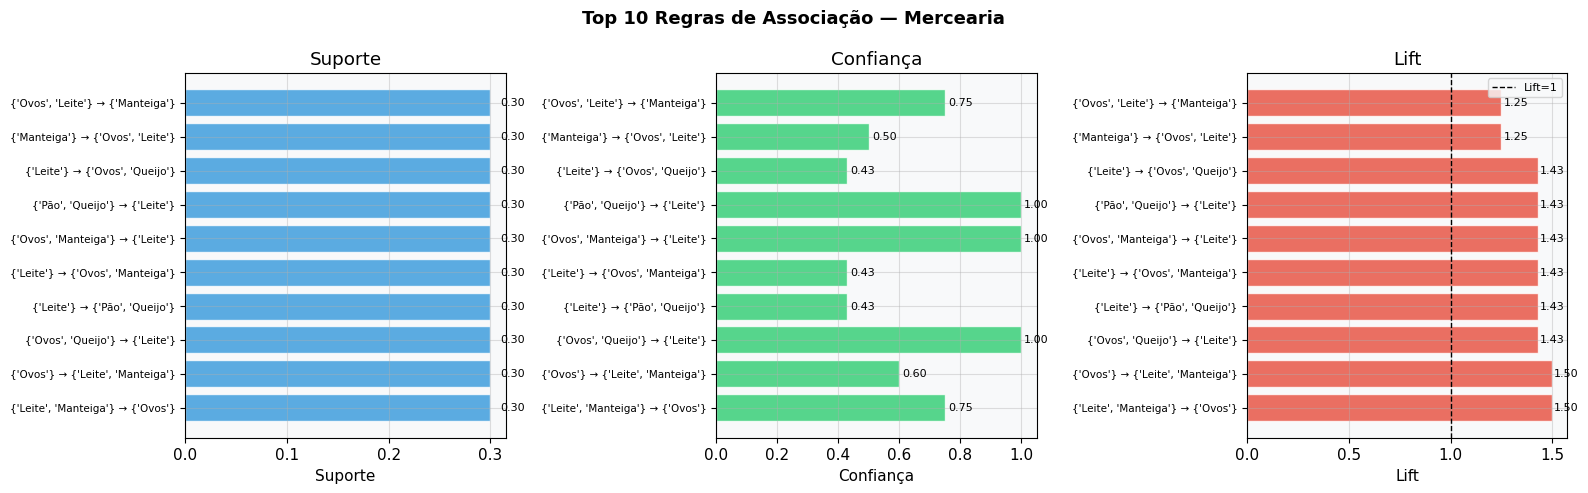

In [10]:
# Visualizando as top regras
top_regras = regras.head(10).copy()
top_regras['regra'] = top_regras.apply(
    lambda r: f"{set(r['antecedents'])} → {set(r['consequents'])}", axis=1
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Top 10 Regras de Associação — Mercearia', fontsize=13, fontweight='bold')

metrics = [('support', '#3498db', 'Suporte'), ('confidence', '#2ecc71', 'Confiança'), ('lift', '#e74c3c', 'Lift')]
for ax, (col, cor, titulo) in zip(axes, metrics):
    bars = ax.barh(range(len(top_regras)), top_regras[col], color=cor, alpha=0.8, edgecolor='white')
    ax.set_yticks(range(len(top_regras)))
    ax.set_yticklabels(top_regras['regra'], fontsize=7.5)
    ax.set_xlabel(titulo)
    ax.set_title(titulo)
    if col == 'lift':
        ax.axvline(1.0, color='black', linestyle='--', linewidth=1, label='Lift=1')
        ax.legend(fontsize=8)
    for bar, val in zip(bars, top_regras[col]):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.2f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

---
# Parte 3 — O Algoritmo FP-Growth

## Ideia Central: Compressão em Árvore

> **"Em vez de adivinhar combinações e verificá-las (Apriori), o FP-Growth desenha um mapa exato dos dados na memória e extrai combinações diretamente desse mapa."**

O FP-Growth resolve os dois gargalos do Apriori:

| Gargalo do Apriori | Solução do FP-Growth |
|--------------------|---------------------|
| Múltiplos scans no disco | **Apenas 2 scans**, o resto ocorre na RAM |
| Explosão de candidatos | **Sem geração de candidatos** — extrai direto da árvore |

## Estrutura FP-Tree (Trie de Prefixos)

A árvore comprime o banco de dados fazendo transações com **prefixos comuns compartilharem o mesmo caminho**.

#### Passo a Passo


O algoritmo funciona em duas grandes fases: primeiro ele constrói a árvore e, em seguida, ele minera essa árvore de baixo para cima.

1. **O Filtro e Ordenação (Scan 1):** Assim como no Apriori, ele faz a primeira varredura no banco para contar a frequência individual de cada item ($k=1$). Ele descarta os raros (abaixo do `min_support`). O grande diferencial aqui é: ele pega os sobreviventes e os **ordena do mais frequente para o menos frequente**.

2. **A Construção da Árvore (Scan 2 e ÚLTIMO):** Ele volta ao banco de dados pela segunda e última vez. Para cada transação, ele pega os itens frequentes (na ordem que definimos no passo 1) e os insere em uma árvore de prefixos (a FP-Tree). 
    *   *Exemplo:* Se a transação 1 é `{Pão, Leite}` e a transação 2 é `{Pão, Café}`, a árvore cria um nó forte para `{Pão}` e depois o divide em dois galhos: um para `{Leite}` e outro para `{Café}`. Transações parecidas compartilham o mesmo caminho, o que comprime enormemente os dados.

3. **A Base de Padrões Condicionais (Divisão):** Com a árvore pronta, o banco de dados não é mais usado. O algoritmo olha para a árvore começando pelos itens **menos frequentes** (que ficam nas folhas da árvore). Para cada item, ele traça o caminho de volta até a raiz para descobrir quais itens vieram antes dele. Esses caminhos formam a "Base de Padrões Condicionais" daquele item.

4. **A Árvore Condicional (Filtro Interno):** Usando apenas os caminhos descobertos no Passo 3, ele constrói uma "Mini FP-Tree" exclusiva para aquele item que está sendo analisado, descartando novamente o que não atingir o `min_support` dentro daquele contexto menor.

5. **Mineração Recursiva (Conquista):** Ele repete o processo 3 e 4 recursivamente para essas mini-árvores, extraindo os padrões frequentes. Como ele está sempre lidando com fragmentos menores da árvore, o processo é extremamente rápido.


Essa estratégia de "Divisão e Conquista" (Passos 3 a 5) evita que o computador tente validar combinações que nunca existiram, pois a árvore só contém os caminhos de compras que **realmente aconteceram**.


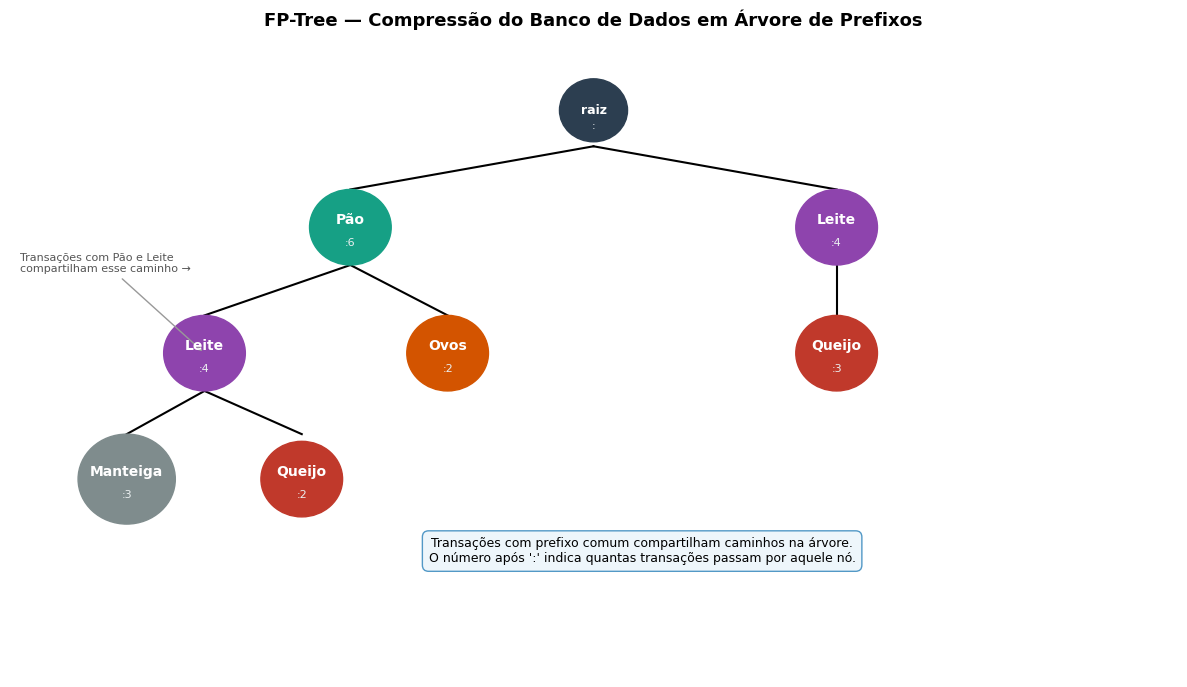

In [30]:
# Visualização didática de uma FP-Tree
fig, ax = plt.subplots(figsize=(12, 7))
ax.set_xlim(0, 12)
ax.set_ylim(0, 7)
ax.axis('off')
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
ax.set_title('FP-Tree — Compressão do Banco de Dados em Árvore de Prefixos', fontsize=13, fontweight='bold', pad=15)

def node(ax, x, y, label, count, color='#2980b9', r=0.42):
    circ = plt.Circle((x, y), r, color=color, zorder=3)
    ax.add_patch(circ)
    ax.text(x, y + 0.08, label, ha='center', va='center', fontsize=10, color='white', fontweight='bold', zorder=4)
    ax.text(x, y - 0.18, f':{count}', ha='center', va='center', fontsize=8, color='#ecf0f1', zorder=4)

def edge(ax, x1, y1, x2, y2):
    ax.plot([x1, x2], [y1, y2], 'k-', lw=1.5, zorder=2)

# Raiz
node(ax, 6, 6.3, '', '', '#2c3e50', r=0.35)
ax.text(6, 6.3, 'raiz', ha='center', va='center', fontsize=9, color='white', fontweight='bold', zorder=5)

# Nível 1: Pão:6, Leite:4
node(ax, 3.5, 5.0, 'Pão', 6, '#16a085')
node(ax, 8.5, 5.0, 'Leite', 4, '#8e44ad')
edge(ax, 6, 5.9, 3.5, 5.42)
edge(ax, 6, 5.9, 8.5, 5.42)

# Nível 2 sob Pão
node(ax, 2.0, 3.6, 'Leite', 4, '#8e44ad')
node(ax, 4.5, 3.6, 'Ovos', 2,  '#d35400')
edge(ax, 3.5, 4.58, 2.0, 4.02)
edge(ax, 3.5, 4.58, 4.5, 4.02)

# Nível 2 sob Leite (galho direito)
node(ax, 8.5, 3.6, 'Queijo', 3, '#c0392b')
edge(ax, 8.5, 4.58, 8.5, 4.02)

# Nível 3 sob Pão→Leite
node(ax, 1.2, 2.2, 'Manteiga', 3, '#7f8c8d', r=0.5)
node(ax, 3.0, 2.2, 'Queijo',   2, '#c0392b')
edge(ax, 2.0, 3.18, 1.2, 2.7)
edge(ax, 2.0, 3.18, 3.0, 2.7)

# Anotações explicativas
ax.annotate('Transações com Pão e Leite\ncompartilham esse caminho →',
            xy=(2.0, 3.6), xytext=(0.1, 4.5),
            fontsize=8, color='#555',
            arrowprops=dict(arrowstyle='->', color='#999', lw=1))

ax.text(6.5, 1.4,
        "Transações com prefixo comum compartilham caminhos na árvore.\n"
        "O número após ':' indica quantas transações passam por aquele nó.",
        fontsize=9, ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#eaf4fb', edgecolor='#2980b9', alpha=0.8))

plt.tight_layout()
plt.show()

In [31]:
# FP-Growth no mesmo dataset
frequent_itemsets_fp = fpgrowth(df_ohe, min_support=MIN_SUPPORT, use_colnames=True)
frequent_itemsets_fp['tamanho'] = frequent_itemsets_fp['itemsets'].apply(len)
frequent_itemsets_fp = frequent_itemsets_fp.sort_values('support', ascending=False)

print(f"Itemsets frequentes encontrados pelo FP-Growth (min_support={MIN_SUPPORT}):")
print(frequent_itemsets_fp.to_string(index=False))

# Confirmando que os resultados são idênticos
set_apriori = set(frozenset(x) for x in frequent_itemsets_apriori['itemsets'])
set_fp      = set(frozenset(x) for x in frequent_itemsets_fp['itemsets'])
print(f"\n✅ Resultados idênticos: {set_apriori == set_fp}")
print(f"   Apriori:   {len(set_apriori)} itemsets")
print(f"   FP-Growth: {len(set_fp)} itemsets")

Itemsets frequentes encontrados pelo FP-Growth (min_support=0.1):
 support                                                                                                                             itemsets  tamanho
0.883544                                                                                                  frozenset({escola=Gabriel_Pereira})        1
0.832911                                                                                                            frozenset({internet=sim})        1
0.789873                                                                                                     frozenset({reprovacoes=nenhuma})        1
0.777215                                                                                                             frozenset({zona=urbana})        1
0.751899                                                                                    frozenset({escola=Gabriel_Pereira, internet=sim})        2
0.724051                    

---
# Parte 4 — Apriori vs FP-Growth

Agora vamos medir o desempenho real dos dois algoritmos variando os principais parâmetros do problema.

## Parâmetros 

In [13]:
# ==============================================================
#   CONFIGURAÇÃO DO BENCHMARK — EDITE AQUI
# ==============================================================

# --- Dataset Base ---
NUM_TRANSACOES    = 5_000    # Número de transações no dataset base
NUM_ITENS_CATALOGO = 21      # Tamanho do vocabulário (d) no dataset base
TAMANHO_MAX_CESTA  = 18     # Máximo de itens por transação
ZIPF_ALPHA         = 1.5     # Parâmetro da distribuição Zipfiana (>1 = mais desigual)
SEED               = 42

# --- Parâmetros de Mineração ---
MIN_SUPPORT_BASE   = 0.03    # Suporte mínimo no benchmark base
MIN_CONFIDENCE     = 0.5     # Confiança mínima para geração de regras

# --- Variações para os experimentos ---
VARIACOES_TRANSACOES  = [500, 1_000, 2_500, 5_000, 10_000, 20_000]   # Experimento 1
VARIACOES_SUPORTE     = [0.005,0.01, 0.02, 0.03, 0.05, 0.10]       # Experimento 2
VARIACOES_ITENS       = [20, 30, 50, 75, 100, 200]                 # Experimento 3

# ==============================================================
np.random.seed(SEED)
print("✅ Configuração carregada!")
print(f"   Dataset base: {NUM_TRANSACOES:,} transações × {NUM_ITENS_CATALOGO} itens únicos")
print(f"   Suporte mínimo: {MIN_SUPPORT_BASE} | Confiança mínima: {MIN_CONFIDENCE}")

✅ Configuração carregada!
   Dataset base: 5,000 transações × 21 itens únicos
   Suporte mínimo: 0.03 | Confiança mínima: 0.5


In [14]:
def gerar_dataset(n_transacoes, n_itens, tamanho_max=15, alpha=1.5, seed=42):
    """Gera dataset sintético com distribuição Zipfiana (simula compras reais)."""
    np.random.seed(seed)
    probs = np.random.zipf(a=alpha, size=n_itens).astype(float)
    probs /= probs.sum()
    catalogo = [f"Item_{i:03d}" for i in range(n_itens)]
    dataset = []
    for _ in range(n_transacoes):
        tam = np.random.randint(1, min(tamanho_max, n_itens))
        cesta = np.random.choice(catalogo, size=tam, p=probs, replace=False)
        dataset.append(list(cesta))
    return dataset


def preparar_ohe(dataset):
    """Converte lista de transações para DataFrame One-Hot Encoding."""
    te = TransactionEncoder()
    return pd.DataFrame(te.fit(dataset).transform(dataset), columns=te.columns_)


def benchmark(df_ohe, min_support):
    """Executa Apriori e FP-Growth, retorna tempos e contagens."""
    resultados = {}
    for nome, func in [('Apriori', apriori), ('FP-Growth', fpgrowth)]:
        t0 = time.perf_counter()
        result = func(df_ohe, min_support=min_support, use_colnames=True)
        elapsed = time.perf_counter() - t0
        resultados[nome] = {'tempo': elapsed, 'n_itemsets': len(result)}
    return resultados


print("✅ Funções auxiliares definidas")

✅ Funções auxiliares definidas


## Experimento 1 — Variando o Número de Transações

Mantendo fixo: número de itens, suporte mínimo. Variando apenas o volume de dados.

In [15]:
print("🔄 Experimento 1: Variando Número de Transações...")
resultados_exp1 = []

for n in VARIACOES_TRANSACOES:
    ds  = gerar_dataset(n, NUM_ITENS_CATALOGO, TAMANHO_MAX_CESTA, ZIPF_ALPHA)
    ohe = preparar_ohe(ds)
    res = benchmark(ohe, MIN_SUPPORT_BASE)
    for algo, vals in res.items():
        resultados_exp1.append({'N_Transacoes': n, 'Algoritmo': algo, **vals})
    print(f"   N={n:>6,}  | Apriori: {res['Apriori']['tempo']:.3f}s  | FP-Growth: {res['FP-Growth']['tempo']:.3f}s  | Itemsets: {res['Apriori']['n_itemsets']}")

df_exp1 = pd.DataFrame(resultados_exp1)
print("✅ Experimento 1 concluído")

🔄 Experimento 1: Variando Número de Transações...
   N=   500  | Apriori: 1.138s  | FP-Growth: 0.740s  | Itemsets: 129439
   N= 1,000  | Apriori: 1.114s  | FP-Growth: 0.860s  | Itemsets: 128561
   N= 2,500  | Apriori: 1.521s  | FP-Growth: 0.978s  | Itemsets: 114330
   N= 5,000  | Apriori: 2.589s  | FP-Growth: 0.970s  | Itemsets: 113193
   N=10,000  | Apriori: 3.635s  | FP-Growth: 1.155s  | Itemsets: 111151
   N=20,000  | Apriori: 7.207s  | FP-Growth: 1.362s  | Itemsets: 111081
✅ Experimento 1 concluído


## Experimento 2 — Variando o Suporte Mínimo

Suporte menor → mais itemsets encontrados → trabalho maior. Vemos como cada algoritmo reage.

In [16]:
print("🔄 Experimento 2: Variando Suporte Mínimo...")
ds_base  = gerar_dataset(NUM_TRANSACOES, NUM_ITENS_CATALOGO, TAMANHO_MAX_CESTA, ZIPF_ALPHA)
ohe_base = preparar_ohe(ds_base)
resultados_exp2 = []

for sup in VARIACOES_SUPORTE:
    res = benchmark(ohe_base, sup)
    for algo, vals in res.items():
        resultados_exp2.append({'min_support': sup, 'Algoritmo': algo, **vals})
    print(f"   sup={sup:.2f} | Apriori: {res['Apriori']['tempo']:.3f}s  | FP-Growth: {res['FP-Growth']['tempo']:.3f}s  | Itemsets: {res['Apriori']['n_itemsets']}")

df_exp2 = pd.DataFrame(resultados_exp2)
print("✅ Experimento 2 concluído")

🔄 Experimento 2: Variando Suporte Mínimo...
   sup=0.01 | Apriori: 13.706s  | FP-Growth: 4.838s  | Itemsets: 749443
   sup=0.01 | Apriori: 8.092s  | FP-Growth: 3.316s  | Itemsets: 432215
   sup=0.02 | Apriori: 3.370s  | FP-Growth: 1.790s  | Itemsets: 204949
   sup=0.03 | Apriori: 1.934s  | FP-Growth: 1.000s  | Itemsets: 113193
   sup=0.05 | Apriori: 0.911s  | FP-Growth: 0.610s  | Itemsets: 45835
   sup=0.10 | Apriori: 0.175s  | FP-Growth: 0.174s  | Itemsets: 9525
✅ Experimento 2 concluído


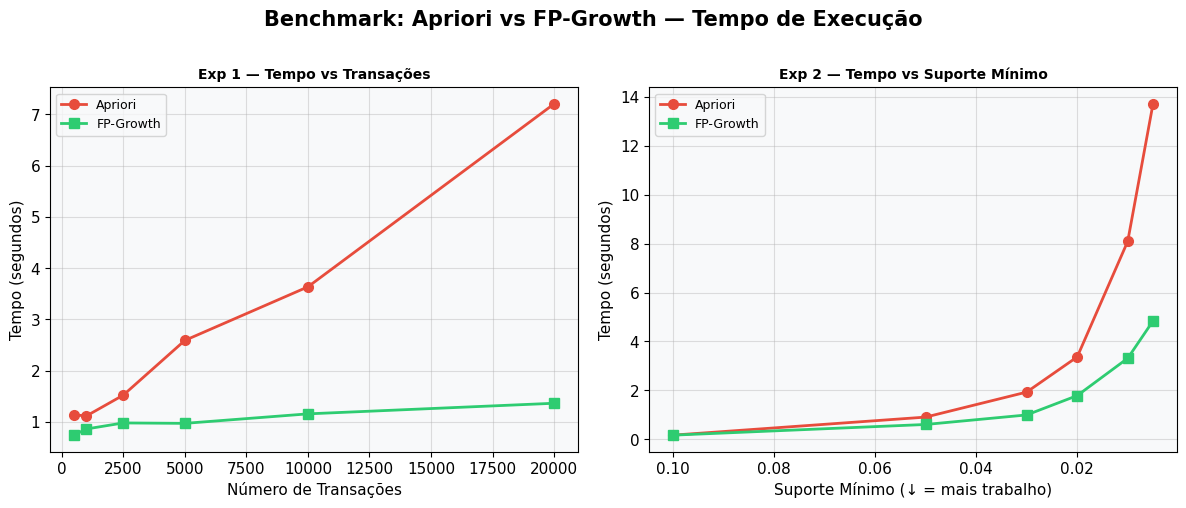

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Benchmark: Apriori vs FP-Growth — Tempo de Execução', fontsize=15, fontweight='bold', y=1.01)

CORES = {'Apriori': '#e74c3c', 'FP-Growth': '#2ecc71'}
MARCADORES = {'Apriori': 'o', 'FP-Growth': 's'}

configs = [
    # (df, x_col, xlabel, title_tempo)
    (df_exp1, 'N_Transacoes', 'Número de Transações',
     'Exp 1 — Tempo vs Transações'),
    (df_exp2, 'min_support',  'Suporte Mínimo',
     'Exp 2 — Tempo vs Suporte Mínimo'),
]

for col_idx, (df, x_col, xlabel, t_tempo) in enumerate(configs):
    ax_tempo = axes[col_idx]

    for algo in ['Apriori', 'FP-Growth']:
        sub = df[df['Algoritmo'] == algo]
        ax_tempo.plot(sub[x_col], sub['tempo'], marker=MARCADORES[algo],
                      color=CORES[algo], linewidth=2, markersize=7, label=algo)

    ax_tempo.set_xlabel(xlabel)
    ax_tempo.set_title(t_tempo, fontweight='bold', fontsize=10)
    ax_tempo.set_ylabel('Tempo (segundos)')
    ax_tempo.legend(fontsize=9)

    # Suporte: eixo x invertido (menor suporte = mais trabalho, fica à direita)
    if x_col == 'min_support':
        ax_tempo.invert_xaxis()
        ax_tempo.set_xlabel('Suporte Mínimo (↓ = mais trabalho)')

plt.tight_layout()
plt.show()

## Pq isso aconteceu ?

- Menor suporte = Mais candidatos 
- Mais Transacoes = Mais leituras em memoria

## Speedup do FP-Growth sobre o Apriori

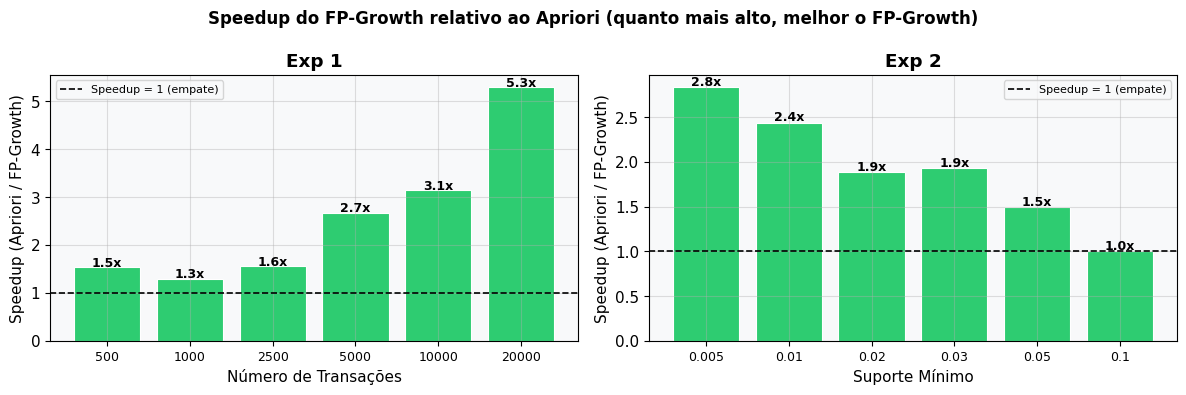

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Speedup do FP-Growth relativo ao Apriori (quanto mais alto, melhor o FP-Growth)',
             fontsize=12, fontweight='bold')

configs_speedup = [
    (df_exp1, 'N_Transacoes', 'Número de Transações', 'Exp 1'),
    (df_exp2, 'min_support',  'Suporte Mínimo',        'Exp 2'),
]

for ax, (df, x_col, xlabel, titulo) in zip(axes, configs_speedup):
    pivot = df.pivot(index=x_col, columns='Algoritmo', values='tempo').reset_index()
    pivot['speedup'] = pivot['Apriori'] / pivot['FP-Growth']

    cores = ['#2ecc71' if s >= 1 else '#e74c3c' for s in pivot['speedup']]
    bars = ax.bar(range(len(pivot)), pivot['speedup'], color=cores, edgecolor='white', linewidth=0.8)
    ax.axhline(1.0, color='black', linestyle='--', linewidth=1.2, label='Speedup = 1 (empate)')
    ax.set_xticks(range(len(pivot)))
    ax.set_xticklabels([str(v) for v in pivot[x_col]], fontsize=9)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Speedup (Apriori / FP-Growth)')
    ax.set_title(titulo, fontweight='bold')
    ax.legend(fontsize=8)
    for bar, val in zip(bars, pivot['speedup']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.1f}x', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

In [19]:

print("\n" + "="*60)
print("CONCLUSÃO")
print("="*60)
print("""
✅ FP-Growth é geralmente superior ao Apriori em:
   • Datasets com muitas transações
   • Suporte mínimo baixo (muitos itemsets frequentes)
   • Catálogos com muitos itens únicos

✅ Apriori pode ser preferível quando:
   • O dataset é pequeno e cabe facilmente na memória
   • O suporte mínimo é alto (poucos candidatos)
   • Transparência e simplicidade de implementação importam

⚠️  Ambos os algoritmos resolvem apenas a Etapa 1 (itemsets frequentes).
    As regras de associação são extraídas na Etapa 2 com association_rules().
""")


CONCLUSÃO

✅ FP-Growth é geralmente superior ao Apriori em:
   • Datasets com muitas transações
   • Suporte mínimo baixo (muitos itemsets frequentes)
   • Catálogos com muitos itens únicos

✅ Apriori pode ser preferível quando:
   • O dataset é pequeno e cabe facilmente na memória
   • O suporte mínimo é alto (poucos candidatos)
   • Transparência e simplicidade de implementação importam

⚠️  Ambos os algoritmos resolvem apenas a Etapa 1 (itemsets frequentes).
    As regras de associação são extraídas na Etapa 2 com association_rules().



---
# Parte 5 — Aplicação em Dados Reais: Student Performance (UCI)

## Por que esse dataset?

O dataset **Student Performance** do UCI Machine Learning Repository contém informações de alunos do ensino médio em Portugal — aprovação/reprovação, hábitos de estudo, vida social, suporte familiar, consumo de álcool, entre outros.

Aqui **não há transações de supermercado**. O desafio é mostrar que regras de associação podem ser extraídas de **qualquer tabela tabular** — desde que façamos a tradução correta do problema.

## A Tradução do Problema

A mineração de regras de associação espera como entrada um conjunto de **transações**, onde cada transação é um conjunto de **itens presentes**.

Para dados tabulares, a tradução é feita em duas etapas:

| Tipo de Coluna | Estratégia | Exemplo |
|---|---|---|
| **Categórica** | Criar um item `coluna=valor` para cada categoria | `escola=GP`, `sexo=F` |
| **Numérica contínua** | Discretizar em faixas → tratar como categórica | `idade=[15-16]`, `nota_final=alto` |
| **Binária (0/1)** | Criar item apenas se o valor for 1 (presença) | `suporte_educacional=sim` |

Cada linha da tabela original vira uma **"transação"** contendo os itens correspondentes aos valores daquele aluno.

> **Exemplo:** O aluno da linha 1 tem `escola=GP`, `sexo=F`, `idade=[15-16]`, `tempo_estudo=baixo`, `reprovacoes=nenhuma`, `nota_final=baixo` → isso vira a transação `{escola=GP, sexo=F, idade=[15-16], tempo_estudo=baixo, reprovacoes=nenhuma, nota_final=baixo}`.

## Download e Inspeção do Dataset

In [20]:
import urllib.request
import zipfile, io

# Dataset Student Performance — UCI ML Repository
URL = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00320/student.zip'
print('⬇️  Baixando Student Performance dataset...')
with urllib.request.urlopen(URL) as resp:
    zf = zipfile.ZipFile(io.BytesIO(resp.read()))

# Usaremos a turma de Matemática (student-mat.csv)
with zf.open('student-mat.csv') as f:
    df_raw = pd.read_csv(f, sep=';')

print(f'✅ Dataset carregado: {df_raw.shape[0]} alunos × {df_raw.shape[1]} colunas')
print()
print(df_raw.dtypes.to_string())

⬇️  Baixando Student Performance dataset...
✅ Dataset carregado: 395 alunos × 33 colunas

school          str
sex             str
age           int64
address         str
famsize         str
Pstatus         str
Medu          int64
Fedu          int64
Mjob            str
Fjob            str
reason          str
guardian        str
traveltime    int64
studytime     int64
failures      int64
schoolsup       str
famsup          str
paid            str
activities      str
nursery         str
higher          str
internet        str
romantic        str
famrel        int64
freetime      int64
goout         int64
Dalc          int64
Walc          int64
health        int64
absences      int64
G1            int64
G2            int64
G3            int64


In [21]:
print('Primeiros registros:')
display(df_raw.head(5))
print()
print('Estatísticas das colunas numéricas:')
display(df_raw.describe())

Primeiros registros:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10



Estatísticas das colunas numéricas:


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


## Seleção de Colunas e Tradução para Itens

Vamos selecionar um subconjunto de colunas representativo e aplicar a tradução coluna → item com o padrão `coluna=valor`.

### Colunas escolhidas

| Coluna | Tipo original | Tradução |
|---|---|---|
| `school` | Categórica | item direto: `escola=GP` ou `escola=MS` |
| `sex` | Categórica | `sexo=F` / `sexo=M` |
| `age` | Numérica inteira | Faixa: `[15-16]`, `[17-18]`, `[19+]` |
| `address` | Categórica | `zona=urbana` / `zona=rural` |
| `studytime` | Ordinal 1–4 | Faixa: `estudo=muito_baixo`, `baixo`, `medio`, `alto` |
| `failures` | Numérica discreta 0–4 | Item direto: `reprovacoes=nenhuma`, `uma`, `duas_ou_mais` |
| `internet` | Binária yes/no | `internet=sim` / `internet=nao` |
| `romantic` | Binária yes/no | `namoro=sim` / `namoro=nao` |
| `Walc` | Ordinal 1–5 | Faixa: `alcool_fds=baixo`, `medio`, `alto` |
| `G3` | Nota final 0–20 | Faixa: `nota_final=reprovado(<10)`, `medio`, `bom`, `otimo` |

In [22]:
df = df_raw.copy()

# ── 1. Categóricas diretas ─────────────────────────────────────
df['item_escola']  = 'escola='  + df['school'].map({'GP':'Gabriel_Pereira', 'MS':'Mousinho_Silva'})
df['item_sexo']    = 'sexo='    + df['sex'].map({'F':'feminino', 'M':'masculino'})
df['item_zona']    = 'zona='    + df['address'].map({'U':'urbana', 'R':'rural'})
df['item_internet']= 'internet='+ df['internet'].map({'yes':'sim', 'no':'nao'})
df['item_namoro']  = 'namoro='  + df['romantic'].map({'yes':'sim', 'no':'nao'})

# ── 2. Numéricas discretizadas ────────────────────────────────
# Idade
df['item_idade'] = pd.cut(
    df['age'],
    bins=[0, 16, 18, 99],
    labels=['idade=[15-16]', 'idade=[17-18]', 'idade=[19+]']
).astype(str)

# Tempo de estudo semanal (1=<2h, 2=2-5h, 3=5-10h, 4=>10h)
mapa_estudo = {1: 'estudo=muito_baixo', 2: 'estudo=baixo', 3: 'estudo=medio', 4: 'estudo=alto'}
df['item_estudo'] = df['studytime'].map(mapa_estudo)

# Reprovações anteriores
df['item_reprov'] = df['failures'].apply(
    lambda x: 'reprovacoes=nenhuma' if x == 0 else ('reprovacoes=uma' if x == 1 else 'reprovacoes=duas_ou_mais')
)

# Álcool fim de semana (1=muito baixo ... 5=muito alto)
df['item_alcool'] = pd.cut(
    df['Walc'],
    bins=[0, 2, 3, 5],
    labels=['alcool_fds=baixo', 'alcool_fds=medio', 'alcool_fds=alto']
).astype(str)

# Nota final G3 (0–20)
df['item_nota'] = pd.cut(
    df['G3'],
    bins=[-1, 9, 13, 16, 20],
    labels=['nota=reprovado', 'nota=medio', 'nota=bom', 'nota=otimo']
).astype(str)

# ── 3. Montando as colunas de itens ──────────────────────────
colunas_itens = [c for c in df.columns if c.startswith('item_')]
print(f'Colunas de itens criadas ({len(colunas_itens)}):')
for c in colunas_itens:
    print(f'  {c:25s} → valores únicos: {sorted(df[c].unique())}')

Colunas de itens criadas (10):
  item_escola               → valores únicos: ['escola=Gabriel_Pereira', 'escola=Mousinho_Silva']
  item_sexo                 → valores únicos: ['sexo=feminino', 'sexo=masculino']
  item_zona                 → valores únicos: ['zona=rural', 'zona=urbana']
  item_internet             → valores únicos: ['internet=nao', 'internet=sim']
  item_namoro               → valores únicos: ['namoro=nao', 'namoro=sim']
  item_idade                → valores únicos: ['idade=[15-16]', 'idade=[17-18]', 'idade=[19+]']
  item_estudo               → valores únicos: ['estudo=alto', 'estudo=baixo', 'estudo=medio', 'estudo=muito_baixo']
  item_reprov               → valores únicos: ['reprovacoes=duas_ou_mais', 'reprovacoes=nenhuma', 'reprovacoes=uma']
  item_alcool               → valores únicos: ['alcool_fds=alto', 'alcool_fds=baixo', 'alcool_fds=medio']
  item_nota                 → valores únicos: ['nota=bom', 'nota=medio', 'nota=otimo', 'nota=reprovado']


In [23]:
# ── 4. Construindo as transações (cada aluno = uma transação) ─
transacoes_alunos = df[colunas_itens].values.tolist()

# Exemplo dos 3 primeiros alunos
print('Exemplos de transações (primeiros 3 alunos):')
print('=' * 60)
for i, t in enumerate(transacoes_alunos[:3]):
    print(f'Aluno {i+1}: {sorted(t)}')
    print()

print(f'Total de transações (alunos): {len(transacoes_alunos)}')
print(f'Tamanho de cada transação:    {len(transacoes_alunos[0])} itens (um por coluna)')

Exemplos de transações (primeiros 3 alunos):
Aluno 1: ['alcool_fds=baixo', 'escola=Gabriel_Pereira', 'estudo=baixo', 'idade=[17-18]', 'internet=nao', 'namoro=nao', 'nota=reprovado', 'reprovacoes=nenhuma', 'sexo=feminino', 'zona=urbana']

Aluno 2: ['alcool_fds=baixo', 'escola=Gabriel_Pereira', 'estudo=baixo', 'idade=[17-18]', 'internet=sim', 'namoro=nao', 'nota=reprovado', 'reprovacoes=nenhuma', 'sexo=feminino', 'zona=urbana']

Aluno 3: ['alcool_fds=medio', 'escola=Gabriel_Pereira', 'estudo=baixo', 'idade=[15-16]', 'internet=sim', 'namoro=nao', 'nota=medio', 'reprovacoes=duas_ou_mais', 'sexo=feminino', 'zona=urbana']

Total de transações (alunos): 395
Tamanho de cada transação:    10 itens (um por coluna)


In [24]:
# ── 5. Codificação One-Hot para o mlxtend ────────────────────
te = TransactionEncoder()
te_array = te.fit(transacoes_alunos).transform(transacoes_alunos)
df_ohe = pd.DataFrame(te_array, columns=te.columns_)

print(f'Dimensões da matriz One-Hot: {df_ohe.shape}')
print(f'Itens (colunas): {list(df_ohe.columns)}')
print()
print('Suporte de cada item (frequência relativa no dataset):')
suporte_itens = df_ohe.mean().sort_values(ascending=False)
print(suporte_itens.to_string())

Dimensões da matriz One-Hot: (395, 27)
Itens (colunas): ['alcool_fds=alto', 'alcool_fds=baixo', 'alcool_fds=medio', 'escola=Gabriel_Pereira', 'escola=Mousinho_Silva', 'estudo=alto', 'estudo=baixo', 'estudo=medio', 'estudo=muito_baixo', 'idade=[15-16]', 'idade=[17-18]', 'idade=[19+]', 'internet=nao', 'internet=sim', 'namoro=nao', 'namoro=sim', 'nota=bom', 'nota=medio', 'nota=otimo', 'nota=reprovado', 'reprovacoes=duas_ou_mais', 'reprovacoes=nenhuma', 'reprovacoes=uma', 'sexo=feminino', 'sexo=masculino', 'zona=rural', 'zona=urbana']

Suporte de cada item (frequência relativa no dataset):
escola=Gabriel_Pereira      0.883544
internet=sim                0.832911
reprovacoes=nenhuma         0.789873
zona=urbana                 0.777215
namoro=nao                  0.665823
alcool_fds=baixo            0.597468
sexo=feminino               0.526582
estudo=baixo                0.501266
sexo=masculino              0.473418
idade=[15-16]               0.470886
idade=[17-18]               0.455696


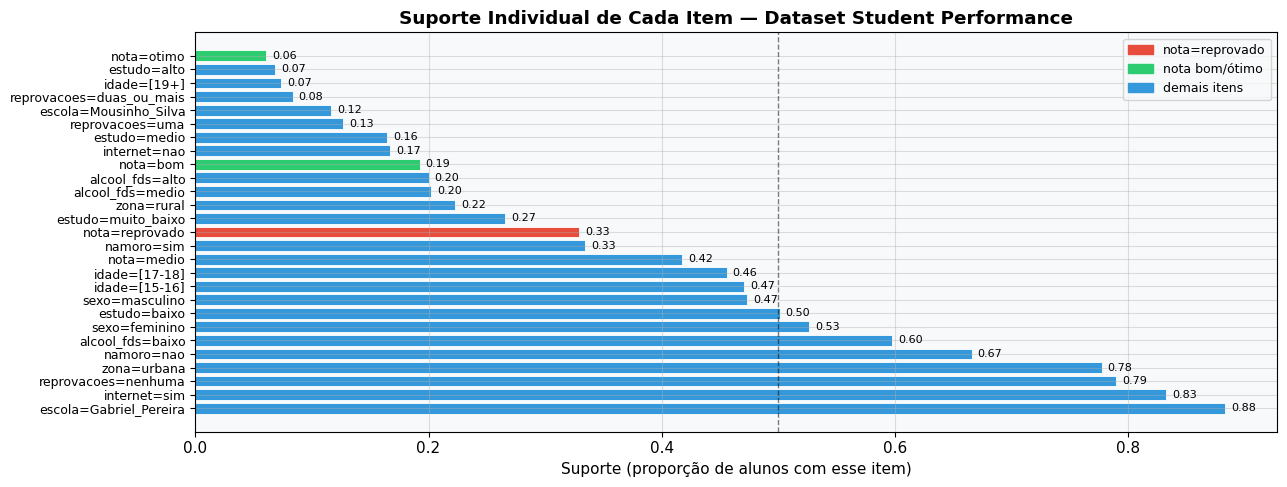

In [25]:
fig, ax = plt.subplots(figsize=(13, 5))
cores = ['#e74c3c' if 'nota=reprovado' in i else
         '#2ecc71' if 'nota=otimo' in i or 'nota=bom' in i else
         '#3498db' for i in suporte_itens.index]
bars = ax.barh(range(len(suporte_itens)), suporte_itens.values,
               color=cores, edgecolor='white', linewidth=0.6)
ax.set_yticks(range(len(suporte_itens)))
ax.set_yticklabels(suporte_itens.index, fontsize=9)
ax.set_xlabel('Suporte (proporção de alunos com esse item)')
ax.set_title('Suporte Individual de Cada Item — Dataset Student Performance', fontweight='bold')
ax.axvline(0.5, color='black', linestyle='--', linewidth=1, alpha=0.5, label='50%')
for bar, val in zip(bars, suporte_itens.values):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=8)
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#e74c3c', label='nota=reprovado'),
    Patch(color='#2ecc71', label='nota bom/ótimo'),
    Patch(color='#3498db', label='demais itens'),
], fontsize=9)
plt.tight_layout()
plt.show()

## Mineração de Itemsets Frequentes com FP-Growth

Com os dados traduzidos, rodamos o FP-Growth normalmente. Um suporte mínimo de ~10% já é razoável para um dataset de ~395 alunos.

In [26]:
MIN_SUPPORT    = 0.10  # Ao menos 10% dos alunos
MIN_CONFIDENCE = 0.60  # Ao menos 60% de confiança
MIN_LIFT       = 1.2   # Lift acima de 1.2 (correlação positiva relevante)

print(f'Minerando itemsets frequentes (min_support={MIN_SUPPORT})...')
freq_items = fpgrowth(df_ohe, min_support=MIN_SUPPORT, use_colnames=True)
freq_items['tamanho'] = freq_items['itemsets'].apply(len)
freq_items = freq_items.sort_values(['tamanho', 'support'], ascending=[True, False])

print(f'✅ {len(freq_items)} itemsets frequentes encontrados')
print(f"   Tamanho 1: {(freq_items['tamanho']==1).sum()}")
print(f"   Tamanho 2: {(freq_items['tamanho']==2).sum()}")
print(f"   Tamanho 3: {(freq_items['tamanho']==3).sum()}")
print(f"   Tamanho 4+: {(freq_items['tamanho']>=4).sum()}")

Minerando itemsets frequentes (min_support=0.1)...
✅ 1315 itemsets frequentes encontrados
   Tamanho 1: 23
   Tamanho 2: 141
   Tamanho 3: 350
   Tamanho 4+: 801


In [27]:
regras = association_rules(
    freq_items,
    metric='confidence',
    min_threshold=MIN_CONFIDENCE,
    num_itemsets=len(freq_items)
)
regras = regras[regras['lift'] >= MIN_LIFT].copy()
regras = regras.sort_values('lift', ascending=False)
regras['antecedentes'] = regras['antecedents'].apply(lambda x: ', '.join(sorted(x)))
regras['consequentes'] = regras['consequents'].apply(lambda x: ', '.join(sorted(x)))

print(f'Regras geradas (conf≥{MIN_CONFIDENCE}, lift≥{MIN_LIFT}): {len(regras)}')
print()
print(regras[['antecedentes','consequentes','support','confidence','lift']]
      .head(20).to_string(index=False))

Regras geradas (conf≥0.6, lift≥1.2): 1789

                                                                               antecedentes                                                            consequentes  support  confidence     lift
 alcool_fds=baixo, escola=Gabriel_Pereira, reprovacoes=nenhuma, sexo=masculino, zona=urbana                                               idade=[15-16], namoro=nao 0.106329    0.677419 1.925041
                         alcool_fds=baixo, reprovacoes=nenhuma, sexo=masculino, zona=urbana                                               idade=[15-16], namoro=nao 0.106329    0.646154 1.836193
                         alcool_fds=baixo, reprovacoes=nenhuma, sexo=masculino, zona=urbana                       escola=Gabriel_Pereira, idade=[15-16], namoro=nao 0.106329    0.646154 1.836193
                                   escola=Gabriel_Pereira, estudo=muito_baixo, internet=sim                                              namoro=nao, sexo=masculino 0.113924    0.616

## Focando nas Regras sobre `nota=reprovado`

Uma aplicação natural aqui é: **quais combinações de características estão associadas à reprovação?**

Filtramos as regras cujo consequente é `nota=reprovado` e ordenamos por lift.

In [28]:
# Regras que predizem reprovação
reprov_rules = regras[regras['consequentes'] == 'nota=reprovado'].copy()

# Regras que predizem nota boa/ótima
bom_rules = regras[regras['consequentes'].isin(['nota=bom', 'nota=otimo'])].copy()

print(f'Regras → nota=reprovado: {len(reprov_rules)}')
print(f'Regras → nota=bom/otimo: {len(bom_rules)}')
print()
if len(reprov_rules) > 0:
    print('Top regras para REPROVAÇÃO:')
    print(reprov_rules[['antecedentes','consequentes','support','confidence','lift']]
          .head(10).to_string(index=False))
if len(bom_rules) > 0:
    print()
    print('Top regras para NOTA BOA/ÓTIMA:')
    print(bom_rules[['antecedentes','consequentes','support','confidence','lift']]
          .head(10).to_string(index=False))

Regras → nota=reprovado: 0
Regras → nota=bom/otimo: 0



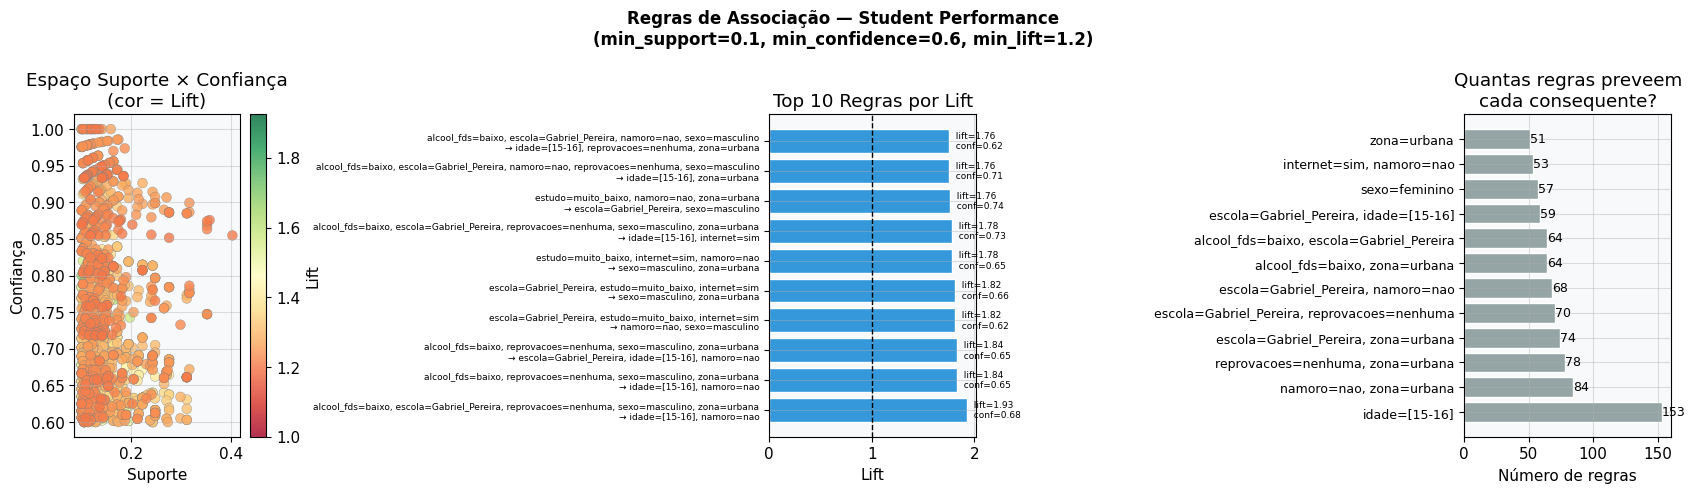

In [29]:
# Painel de visualização das regras
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Regras de Associação — Student Performance\n'
             f'(min_support={MIN_SUPPORT}, min_confidence={MIN_CONFIDENCE}, min_lift={MIN_LIFT})',
             fontsize=12, fontweight='bold')

# Plot 1: Scatter suporte × confiança com lift como cor
sc = axes[0].scatter(
    regras['support'], regras['confidence'],
    c=regras['lift'], cmap='RdYlGn', s=50,
    edgecolors='gray', linewidth=0.3, alpha=0.8, vmin=1, vmax=regras['lift'].max()
)
axes[0].set_xlabel('Suporte')
axes[0].set_ylabel('Confiança')
axes[0].set_title('Espaço Suporte × Confiança\n(cor = Lift)')
plt.colorbar(sc, ax=axes[0], label='Lift')

# Plot 2: Top 10 regras por lift
top10 = regras.head(10)
labels = [f"{r['antecedentes']}\n→ {r['consequentes']}" for _, r in top10.iterrows()]
cores_lift = ['#e74c3c' if 'reprovado' in r['consequentes'] else
              '#2ecc71' if 'bom' in r['consequentes'] or 'otimo' in r['consequentes'] else
              '#3498db' for _, r in top10.iterrows()]
axes[1].barh(range(len(top10)), top10['lift'].values,
             color=cores_lift, edgecolor='white')
axes[1].set_yticks(range(len(top10)))
axes[1].set_yticklabels(labels, fontsize=6.5)
axes[1].axvline(1.0, color='black', linestyle='--', linewidth=1)
axes[1].set_xlabel('Lift')
axes[1].set_title('Top 10 Regras por Lift')
for i, (v, c) in enumerate(zip(top10['lift'].values, top10['confidence'].values)):
    axes[1].text(v + 0.01, i, f'  lift={v:.2f}\n  conf={c:.2f}', va='center', fontsize=6.5)

# Plot 3: Distribuição por consequente
consq_counts = regras['consequentes'].value_counts().head(12)
cores_bar = ['#e74c3c' if 'reprovado' in c else
             '#2ecc71' if 'bom' in c or 'otimo' in c else '#95a5a6'
             for c in consq_counts.index]
axes[2].barh(range(len(consq_counts)), consq_counts.values,
             color=cores_bar, edgecolor='white')
axes[2].set_yticks(range(len(consq_counts)))
axes[2].set_yticklabels(consq_counts.index, fontsize=9)
axes[2].set_xlabel('Número de regras')
axes[2].set_title('Quantas regras preveem\ncada consequente?')
for i, v in enumerate(consq_counts.values):
    axes[2].text(v + 0.1, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.show()

## Como Interpretar as Regras no Contexto Escolar

A leitura das regras é idêntica ao caso do supermercado, apenas o contexto muda:

```json
{reprovacoes=nenhuma, estudo=medio} → {nota=bom} support=0.18   confidence=0.72   lift=1.85
```

Leitura: **"18% dos alunos não têm reprovações e estudam em nível médio; entre eles, 72% tiram nota boa — o que é 1.85× mais frequente do que a proporção geral de alunos com nota boa."**

---

## O Que Fizemos

```sh
Tabela tabular (alunos × atributos)
         ↓
Seleção de colunas relevantes
         ↓
Tradução para itens:
  - Categóricas  → coluna=valor
  - Numéricas    → pd.cut() → coluna=faixa
  - Binárias     → coluna=sim / coluna=nao
         ↓
Cada linha vira uma transação de itens
         ↓
TransactionEncoder → DataFrame One-Hot
         ↓
fpgrowth() + association_rules()  ← exatamente igual ao caso transacional
```
